# 2.1 LangChain vs LangGraph (feat. LangGraph 개념 설명)

- LangChain을 활용한 간단한 `llm.invoke()` 예제를 살펴보고, 이를 LangGraph로 구현해보는 과정을 진행합니다.
- LangGraph의 개념과 주요 기능을 이해하고, 두 프레임워크의 차이점을 비교합니다.

## 환경설정

- `LangChain` 활용을 위해 필요한 패키지들을 설치합니다
- 최신 버전을 설치해도 정상적으로 동작해야 하지만, 버전 명시가 필요하다면 `requirements.txt`를 참고해주세요

In [1]:
%pip install -q python-dotenv langchain-google-genai


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


- 먼저 `.env` 파일의 환경변수를 불러옵니다
- `OPENAI_API_KEY`, `GEMINI_API_KEY`, `ANTHROPIC_API_KEY` 등과 같이 환경변수를 설정하면 편하게 사용할 수 있습니다

In [4]:
from dotenv import load_dotenv

load_dotenv()

True

In [6]:
from langchain_google_genai import ChatGoogleGenerativeAI

query = '인프런에는 어떤 강의가 있나요?'
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
response = llm.invoke(query)
print(response.content)

인프런(Inflearn)은 IT 분야를 중심으로 매우 다양한 온라인 강의를 제공하는 국내 대표적인 학습 플랫폼입니다. 특정 기술이나 분야에 대한 깊이 있는 강의부터 기초 입문 강의까지 폭넓게 찾아볼 수 있습니다.

주요 강의 카테고리는 다음과 같습니다:

1.  **웹 개발 (Web Development)**
    *   **프론트엔드 (Frontend):** HTML/CSS, JavaScript, React, Vue.js, Angular, TypeScript, 웹 퍼블리싱 등
    *   **백엔드 (Backend):** Node.js, Spring (Java), Django/Flask (Python), Ruby on Rails, PHP, Go 언어 기반 프레임워크 등
    *   **데이터베이스:** MySQL, PostgreSQL, MongoDB, Redis 등
    *   **DevOps/배포:** Docker, Kubernetes, CI/CD, Nginx, Apache 등

2.  **모바일 앱 개발 (Mobile App Development)**
    *   **안드로이드 (Android):** Java, Kotlin
    *   **iOS:** Swift, Objective-C
    *   **크로스 플랫폼:** React Native, Flutter

3.  **데이터 과학 / 인공지능 (Data Science / AI)**
    *   **프로그래밍 언어:** Python (Pandas, NumPy, Scikit-learn), R
    *   **머신러닝 (Machine Learning):** 지도학습, 비지도학습, 강화학습 알고리즘
    *   **딥러닝 (Deep Learning):** TensorFlow, PyTorch, CNN, RNN, NLP, 컴퓨터 비전
    *   **데이터 분석 / 시각화:** Tableau, Power BI, Excel을 활용한 데이터 분석
    *   **데이터 엔지니어링:** 빅데이터 

- `LangGraph` 활용을 위해 필요한 패키지를 설치합니다
- 최신 버전을 설치해도 정상적으로 동작해야 하지만, 버전 명시가 필요하다면 `requirements.txt`를 참고해주세요

In [10]:
%pip install -q langgraph

Note: you may need to restart the kernel to use updated packages.


- `state`는 LangGraph 에이전트의 state를 나타내는 데이터 구조입니다.
- `state`는 `TypedDict`를 사용하여 정의되며, 이는 Python의 타입 힌팅을 통해 구조를 명확히 합니다.
    - 지금 예제에서는 간단하게 `messages`라는 필드만 있습니다.
    - 필요에 따라 다양한 값들을 활용할 수 있습니다.
        - 2.2 회차에서 다룰 예정입니다.
- `state`는 에이전트의 동작을 결정하는 데 사용되며, 각 노드에서 state를 업데이트하거나 참조할 수 있습니다.
- `state`는 LangGraph의 노드 간에 전달되며, 에이전트의 state 전이를 관리합니다.

In [11]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage

class AgentState(TypedDict):
    messages: list[Annotated[AnyMessage, add_messages]]

/Users/aaron/.pyenv/versions/inflearn-langgraph-agent/lib/python3.12/site-packages/langgraph/checkpoint/base/__init__.py:24: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


- 위에 선언한 `AgentState`를 활용하여 `StateGraph`를 생성합니다.

In [12]:
from langgraph.graph import StateGraph

graph_builder = StateGraph(AgentState)

- `graph`에 추가할 `node`를 생성합니다
-  `node`는 LangGraph에서 실행되는 개별적인 작업 단위를 의미합니다. 
    - 각 노드는 특정 기능을 수행하는 독립적인 컴포넌트로, 예를 들어 텍스트 생성, 데이터 처리, 또는 의사 결정과 같은 작업을 담당할 수 있습니다.
    - `node`는 기본적으로 함수(function)로 정의되고, 뒤에서 다루지만 다른 에이전트(agent)를 활용할 수도 있습니다

In [13]:
def generate(state: AgentState) -> AgentState:
    """
    `generate` 노드는 사용자의 질문을 받아서 응답을 생성하는 노드입니다.
    """
    messages = state['messages']
    ai_message = llm.invoke(messages)
    return {'messages': [ai_message]}

- `node`를 생성한 후에 `edge`로 연결합니다
- `edge`는 노드들 사이의 연결을 나타내며, 데이터와 제어 흐름의 경로를 정의합니다. 
    - 엣지를 통해 한 노드의 출력이 다음 노드의 입력으로 전달되어, 전체적인 워크플로우가 형성됩니다.
    - `node`와 `edge`의 조합은 방향성 그래프(Directed Graph)를 형성하며, 이를 통해 복잡한 AI 에이전트의 행동 흐름을 구조화할 수 있습니다

In [14]:
graph_builder.add_node('generate', generate)

- 모든 그래프는 `START(시작)`와 `END(종료)`가 있습니다
    - `END`를 explicit하게 선언하지 않는 경우도 종종 있지만, 가독성을 위해 작성해주는 것을 권장합니다

In [15]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'generate')
graph_builder.add_edge('generate', END)

- `node`를 생성하고 `edge`로 연결한 후에 `compile` 메서드를 호출하여 `Graph`를 생성합니다

In [16]:
graph = graph_builder.compile()

- `compile` 후에는 그래프를 시각화하여 확인할 수 있습니다
- 의도한대로 그래프가 생성됐는지 확인하는 습관을 기르는 것이 좋습니다
    - `git`에서 코드 작업물을 commit하기 전에 `git diff`를 통해 변경사항을 확인하는 것과 같습니다

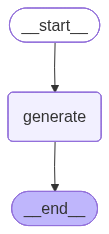

In [17]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [18]:
from langchain_core.messages import HumanMessage

# 사용자의 질문을 `state`에 담아서 `invoke` 메서드를 호출하면, 그래프가 실행
initial_state = {'messages': [HumanMessage(query)]}
graph.invoke(initial_state)

{'messages': [AIMessage(content='인프런(Inflearn)은 주로 **IT/개발 분야 강의로 매우 유명**하지만, 최근에는 그 외 다양한 분야의 강의들도 많이 늘어나면서 폭넓은 학습 콘텐츠를 제공하고 있습니다.\n\n크게 다음과 같은 분야의 강의들을 찾아볼 수 있습니다.\n\n1.  **IT/개발 (가장 큰 비중):**\n    *   **프로그래밍 언어:** Python, Java, JavaScript, C#, C++, Go, Kotlin, Swift, PHP, Ruby 등\n    *   **웹 개발:**\n        *   **프론트엔드:** React, Vue.js, Angular, HTML/CSS, TypeScript, 웹 성능 최적화 등\n        *   **백엔드:** Spring Boot (Java), Node.js (Express), Django/Flask (Python), Ruby on Rails, Go 언어 기반 프레임워크 등\n        *   **풀스택:** 프론트엔드와 백엔드를 아우르는 과정\n    *   **모바일 앱 개발:** Android (Kotlin/Java), iOS (Swift/Objective-C), Flutter, React Native 등\n    *   **데이터 과학/인공지능(AI)/머신러닝(ML):** 파이썬 기반 데이터 분석, R, 텐서플로우(TensorFlow), 파이토치(PyTorch), 딥러닝, 머신러닝 알고리즘, 빅데이터 처리 등\n    *   **클라우드 컴퓨팅:** AWS, Azure, GCP, Kubernetes, Docker, 컨테이너 기술 등\n    *   **DevOps:** CI/CD, Git, GitHub/GitLab, Jenkins, 서버 관리 (Linux), 네트워크 등\n    *   **데이터베이스:** MySQL, PostgreSQL, MongoDB, Redis, SQL 기본 등\n    *   **게임 개발:** Unity, Unreal